In [48]:
from mnist import MNIST
import numpy as np

mndata = MNIST(r'C:\Users\jitik\OneDrive\Desktop\Hands_on_ML_aurelion_geron\Chapter_10_geron\mnist')
images, labels = mndata.load_training()
test_images, test_labels = mndata.load_testing()

X_train = np.array(images)  / 255.0
y_train = np.array(labels)

X_test = np.array(test_images) / 255.0
y_test = np.array(test_labels)

print(X_train.shape)
print(y_train.shape)  

(60000, 784)
(60000,)


In [49]:
input_dimension = 784
input_layer_dimension = input_dimension
output_layer_dimension = 10
num_classes = 10
layers = 3 # includes hidden + output layer
layer_dimension = (134, 72, output_layer_dimension)  # How many neurons in each layer
assert layers >= 1
assert layers == len(layer_dimension)

In [50]:
def initialize_weights_and_biases_randomly(input_dimension: int, layer_dimension: tuple):
    weights_matrix = []
    bias_matrix = []

    in_dim = input_dimension
    for out_dim in layer_dimension:
        weight = np.random.randn(in_dim, out_dim) * np.sqrt(2.0 / in_dim)  # He initialization
        bias = np.full(shape = (1, out_dim),fill_value=0.1,dtype=np.float64)  # Standard: initialize biases to zeros
        # print(weight.shape)
        weights_matrix.append(weight)
        bias_matrix.append(bias)
        in_dim = out_dim  # Update for next layer

    return weights_matrix, bias_matrix


In [51]:
def softmax(z): # This is just a softmax with glorified numerical stability , simple softmax raised warnings 
    assert isinstance(z,np.ndarray)
    z_shift = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [52]:
def Relu(x):
    return np.maximum(0,x)
def relu_diff(x):
    return np.heaviside(x,1)

In [53]:
def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

In [54]:
def cross_entropy(y_hat, y): # Stack overflowed this numerically stable cross-entropy , simple one can work too
    eps = 1e-15
    y_hat_clipped = np.clip(y_hat, eps, 1-eps)
    sample_losses = -np.sum(y * np.log(y_hat_clipped), axis=1)
    return sample_losses

def cross_entropy_diff(predictions,true_label):
    return (predictions - true_label) # y_should be one_hot encoded

In [55]:
def forward_pass(X, weights_matrix, bias_matrix):
    activations = [X]  # store outputs of each layer
    A = X

    for i in range(len(weights_matrix)):
        Z = np.matmul(A, weights_matrix[i]) + bias_matrix[i]  # pre-activation
        if i == len(weights_matrix) - 1:
            A = softmax(Z)  # output layer
        else:
            A = leaky_relu(Z)     # hidden layers
        activations.append(A)

    return activations  # list of all activations layer by layer

In [56]:
def one_hot_encode(y, num_classes):
    y = np.array(y).reshape(-1).astype(int)  # Flatten in case it's shape (n,1)
    new_y = np.zeros((y.shape[0], num_classes), dtype=np.float64)
    new_y[np.arange(y.shape[0]), y] = 1.0
    return new_y

In [57]:
def output_layer_gradient_descent(activations, weights_matrix, bias_matrix, Y_train_encoded, learning_rate):
    layer = -1
    out_activ = activations[layer]
    prev_activ = activations[layer - 1]
    delta = cross_entropy_diff(out_activ, Y_train_encoded)
    weight_grad = prev_activ.T @ delta
    bias_grad = np.sum(delta, axis=0, keepdims=True)

    weight_grad = np.clip(weight_grad, -1.0, 1.0)
    bias_grad = np.clip(bias_grad, -1.0, 1.0)

    prev_layer_grad = delta @ weights_matrix[layer].T
    weights_matrix[layer] -= learning_rate * weight_grad
    bias_matrix[layer] -= learning_rate * bias_grad
    return prev_layer_grad


In [58]:
def hidden_layer_gradient_descent(activations, weights_matrix, bias_matrix, post_layer_gradient, learning_rate):
    num_layers = len(weights_matrix)
    for i in range(2, num_layers + 1):
        layer = -i  # counts -2, -3, ... for hidden layers
        curr_activ = activations[layer]
        prev_activ = activations[layer - 1]
        delta = post_layer_gradient * leaky_relu_derivative(curr_activ)
        # After computing gradients, before weight updates:
        weight_grad = prev_activ.T @ delta
        bias_grad = np.sum(delta, axis=0, keepdims=True)

        weight_grad = np.clip(weight_grad, -1.0, 1.0)
        bias_grad = np.clip(bias_grad, -1.0, 1.0)

        post_layer_gradient = delta @ weights_matrix[layer].T
        weights_matrix[layer] -= learning_rate * weight_grad
        bias_matrix[layer] -= learning_rate * bias_grad

In [59]:
def backpropagate(activations, weights_matrix, bias_matrix, Y_train_encoded, learning_rate):
    hidden_grad = output_layer_gradient_descent(
        activations, weights_matrix, bias_matrix, Y_train_encoded, learning_rate)
    hidden_layer_gradient_descent(
        activations, weights_matrix, bias_matrix, hidden_grad, learning_rate)

In [60]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(epoch, X, y, weights_matrix, bias_matrix, forward_pass, save_dir=None):
    h = 0.02
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    probs = forward_pass(grid, weights_matrix, bias_matrix)[-1]
    Z = np.argmax(probs, axis=1).reshape(xx.shape)

    plt.figure(figsize=(7,5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k', s=40, cmap=plt.cm.coolwarm)
    plt.title(f"Decision Boundary at Epoch {epoch}")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.tight_layout()

    # Create directory if it does not exist
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        filepath = os.path.join(save_dir, f'boundary_epoch_{epoch:03d}.png')
    else:
        filepath = f'boundary_epoch_{epoch:03d}.png'
    
    plt.savefig(filepath)
    plt.close()
    return filepath


In [61]:
def train_neural_network(X, Y, X_t, Y_t, input_dimension: int, layer_dimension: tuple, num_classes: int = 10, epochs: int = 1000, learning_rate: float = 0.001, batch_size: int = 64,decision_boundary : bool = False,decision_boundary_save_dir : str = None) -> tuple:
    assert X.shape[0] == Y.shape[0]
    assert X_t.shape[0] == Y_t.shape[0]
    weights_matrix, bias_matrix = initialize_weights_and_biases_randomly(input_dimension, layer_dimension)
    num_samples = X.shape[0]
    average_loss_history = []
    loss_history = []
    accuracy_history = []

    for epoch in range(epochs):
        # Shuffle the data
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        X = X[indices]
        Y = Y[indices]

        epoch_loss = 0
        num_batches = 0

        for start in range(0, num_samples, batch_size):
            end = start + batch_size
            X_batch = X[start:end]
            Y_batch = Y[start:end]

            activations = forward_pass(X_batch, weights_matrix, bias_matrix)
            output_probs = activations[-1]
            Y_encoded = one_hot_encode(Y_batch, num_classes)
            loss = cross_entropy(output_probs, Y_encoded)
            epoch_loss += np.sum(loss) 
            num_batches += 1

            backpropagate(activations, weights_matrix, bias_matrix, Y_encoded, learning_rate)

        # average_loss = epoch_loss / num_batches

        # Eval on test set 
        test_activations = forward_pass(X_t, weights_matrix, bias_matrix)
        test_output_probs = test_activations[-1]  # shape (num_test_samples, num_classes)
        test_pred_labels = np.argmax(test_output_probs, axis=1)

        test_accuracy = np.mean(test_pred_labels == Y_t)
        average_epoch_loss = epoch_loss/num_batches

        print(f"Epoch {epoch}: average_loss = {average_epoch_loss:.4f},entropy_loss = {epoch_loss :.4f}, test accuracy = {test_accuracy*100:.2f}%")

        average_loss_history.append(average_epoch_loss)
        accuracy_history.append(test_accuracy)
        loss_history.append(epoch_loss)

        if decision_boundary == True:
            # After updating weights/biases in each epoch, save decision boundary
            plot_decision_boundary(epoch, X, Y, weights_matrix, bias_matrix, forward_pass,save_dir=decision_boundary_save_dir)


    return weights_matrix, bias_matrix, np.array(average_loss_history), np.array(accuracy_history) * 100, np.array(loss_history)

In [ ]:
epochs = 3
weights_matrix_final, bias_matrix_final, average_loss_history, accuracy_history,loss_history = train_neural_network(X_train,y_train,X_test,y_test,input_layer_dimension,layer_dimension,10,epochs,0.01,batch_size=32)

Epoch 0: average_loss = 7.6273,entropy_loss = 14301.1416, test accuracy = 96.11%
Epoch 1: average_loss = 3.6265,entropy_loss = 6799.7376, test accuracy = 97.16%
Epoch 2: average_loss = 2.6870,entropy_loss = 5038.0927, test accuracy = 97.19%
Epoch 3: average_loss = 2.1151,entropy_loss = 3965.7430, test accuracy = 97.17%


KeyboardInterrupt: 

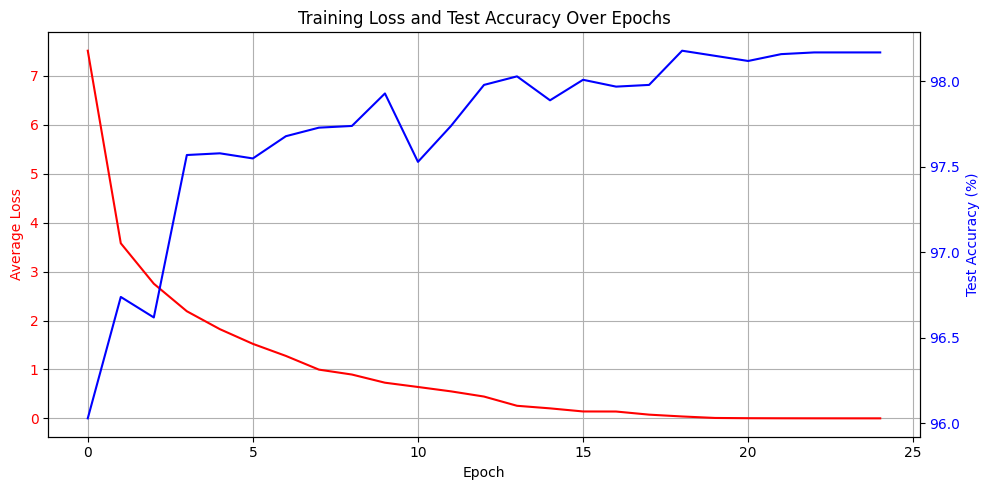

In [ ]:
import matplotlib.pyplot as plt
epoch_range = list(range(epochs))
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Average Loss', color=color)
ax1.plot(epoch_range, average_loss_history, color=color, label='Average Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

ax2 = ax1.twinx()
color = 'blue'
ax2.set_ylabel('Test Accuracy (%)', color=color)
ax2.plot(epoch_range, accuracy_history, color=color, label='Test Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Training Loss and Test Accuracy Over Epochs')
fig.tight_layout()
plt.show()


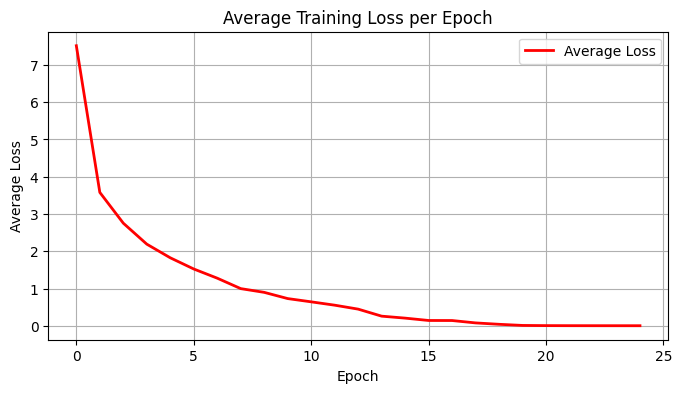

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(average_loss_history, color='red', linewidth=2, label='Average Loss')
plt.title('Average Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.grid(True)
plt.legend()
plt.show()


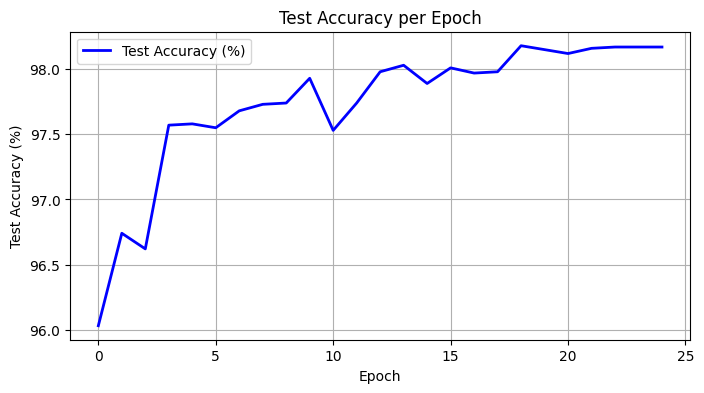

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(accuracy_history, color='blue', linewidth=2, label='Test Accuracy (%)')
plt.title('Test Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.grid(True)
plt.legend()
plt.show()


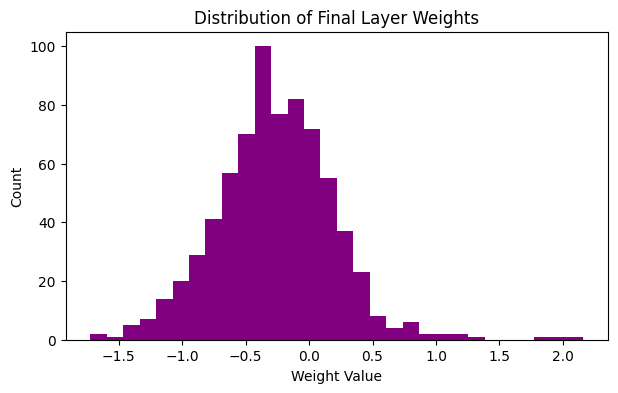

In [ ]:
final_layer_weights = weights_matrix_final[-1].flatten()
plt.figure(figsize=(7,4))
plt.hist(final_layer_weights, bins=30, color='purple')
plt.title('Distribution of Final Layer Weights')
plt.xlabel('Weight Value')
plt.ylabel('Count')
plt.show()


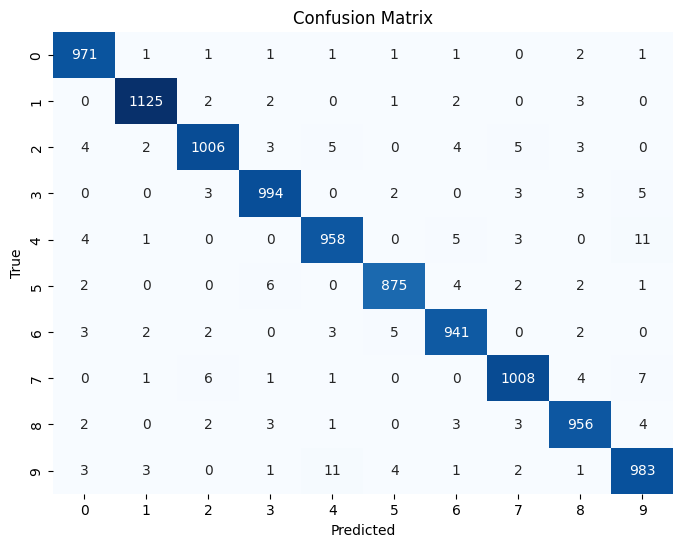

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

test_pred_labels = np.argmax(forward_pass(X_test, weights_matrix_final, bias_matrix_final)[-1], axis=1)
cm = confusion_matrix(y_test, test_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [63]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

fashion_mnist_labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}


In [64]:
X_train = X_train.reshape(60000, 28 * 28)
X_test = X_test.reshape(10000,28 * 28)
X_train.shape

(60000, 784)

In [65]:
y_train.shape

(60000,)

In [66]:
input_dimension = 784
output_dimension = 10
layer_dimension = (128,64,10)
epochs = 100

weights_matrix_final, bias_matrix_final, average_loss_history, accuracy_history,loss_history = train_neural_network(X_train,y_train,X_test,y_test,input_dimension,layer_dimension,10,epochs,0.001,batch_size=64)

Epoch 0: average_loss = 192.3347,entropy_loss = 180409.9352, test accuracy = 73.78%
Epoch 1: average_loss = 346.4416,entropy_loss = 324962.2316, test accuracy = 69.65%
Epoch 2: average_loss = 328.7946,entropy_loss = 308409.2886, test accuracy = 72.58%
Epoch 3: average_loss = 259.0901,entropy_loss = 243026.4703, test accuracy = 74.47%
Epoch 4: average_loss = 188.5409,entropy_loss = 176851.4007, test accuracy = 76.59%
Epoch 5: average_loss = 155.7963,entropy_loss = 146136.9685, test accuracy = 73.83%
Epoch 6: average_loss = 148.5891,entropy_loss = 139376.5552, test accuracy = 71.09%
Epoch 7: average_loss = 124.2635,entropy_loss = 116559.1997, test accuracy = 74.17%
Epoch 8: average_loss = 112.1077,entropy_loss = 105157.0119, test accuracy = 73.31%
Epoch 9: average_loss = 113.3136,entropy_loss = 106288.1287, test accuracy = 72.48%
Epoch 10: average_loss = 91.5920,entropy_loss = 85913.2954, test accuracy = 74.93%
Epoch 11: average_loss = 80.6685,entropy_loss = 75667.0768, test accuracy = 7

KeyboardInterrupt: 

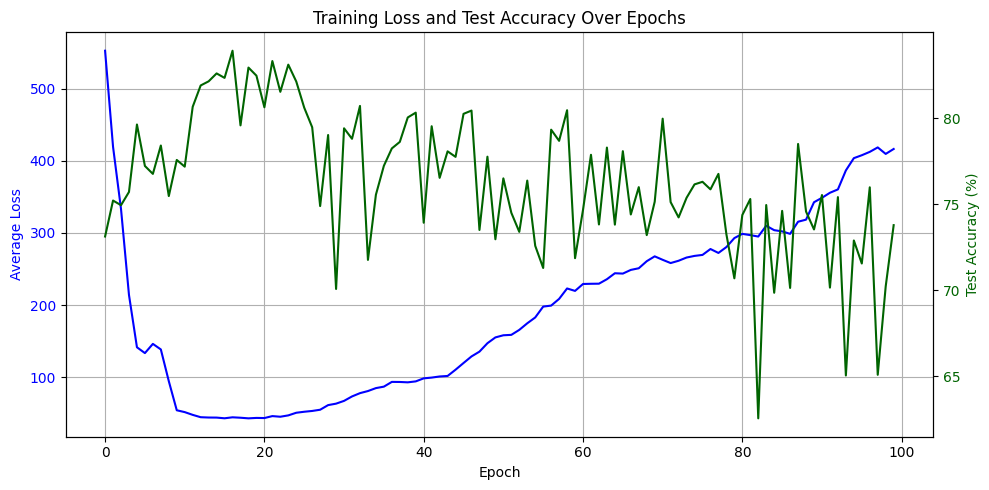

In [ ]:
import matplotlib.pyplot as plt
epoch_range = list(range(epochs))
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Average Loss', color=color)
ax1.plot(epoch_range, average_loss_history, color=color, label='Average Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

ax2 = ax1.twinx()
color = 'darkgreen'
ax2.set_ylabel('Test Accuracy (%)', color=color)
ax2.plot(epoch_range, accuracy_history, color=color, label='Test Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Training Loss and Test Accuracy Over Epochs')
fig.tight_layout()
plt.show()


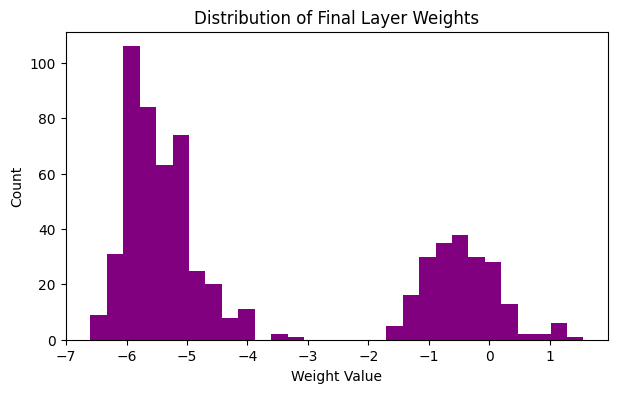

In [ ]:
final_layer_weights = weights_matrix_final[-1].flatten()
plt.figure(figsize=(7,4))
plt.hist(final_layer_weights, bins=30, color='purple')
plt.title('Distribution of Final Layer Weights')
plt.xlabel('Weight Value')
plt.ylabel('Count')
plt.show()

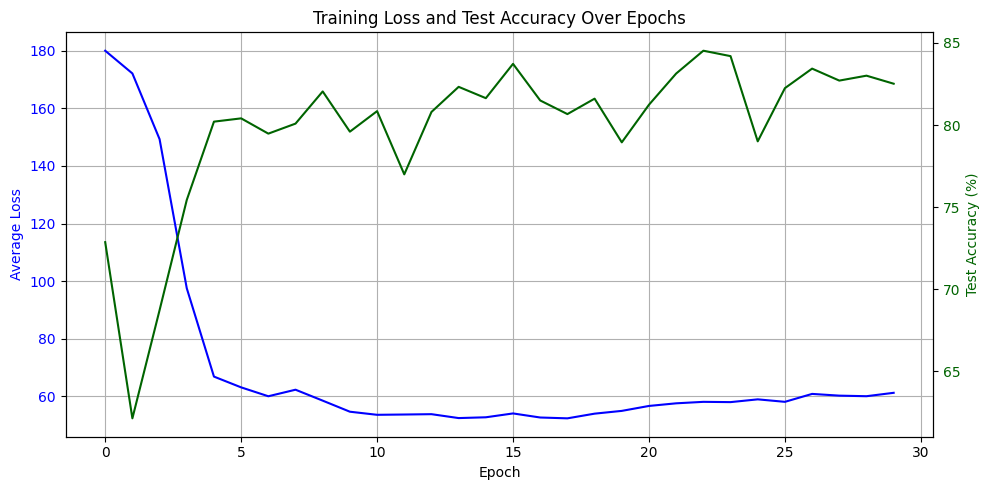

In [59]:
from sklearn.datasets import make_moons

X,Y = make_moons(n_samples=1000,noise = 0.13,random_state=42)
X_train,Y_train,X_test,Y_test = X[:800],Y[:800],X[200:],Y[200:]

input_dimension = 2
output_dimension = 2
layer_dimension = (5,5,output_dimension)
num_classes = output_dimension
epochs = 300
test_size = X_train.shape[0]
batch_size = X_train.shape[0]
learning_rate_moons = 0.01

weights_matrix_final, bias_matrix_final, average_loss_history, accuracy_history,loss_history = train_neural_network(X_train,Y_train,X_test,Y_test,input_dimension,layer_dimension,num_classes,epochs,learning_rate_moons,batch_size=batch_size,decision_boundary=True,decision_boundary_save_dir=r'C:\Users\jitik\OneDrive\Desktop\Hands_on_ML_aurelion_geron\Chapter_10_geron\decision_boundary_moons_dir')

Epoch 0: average_loss = 430.1492,entropy_loss = 430.1492, test accuracy = 77.25%
Epoch 1: average_loss = 393.4528,entropy_loss = 393.4528, test accuracy = 80.25%
Epoch 2: average_loss = 363.4782,entropy_loss = 363.4782, test accuracy = 81.25%
Epoch 3: average_loss = 338.3264,entropy_loss = 338.3264, test accuracy = 82.50%
Epoch 4: average_loss = 317.9042,entropy_loss = 317.9042, test accuracy = 83.38%
Epoch 5: average_loss = 301.7897,entropy_loss = 301.7897, test accuracy = 83.38%
Epoch 6: average_loss = 288.3179,entropy_loss = 288.3179, test accuracy = 84.38%
Epoch 7: average_loss = 276.9326,entropy_loss = 276.9326, test accuracy = 85.38%
Epoch 8: average_loss = 267.3967,entropy_loss = 267.3967, test accuracy = 85.50%
Epoch 9: average_loss = 258.9662,entropy_loss = 258.9662, test accuracy = 86.12%
Epoch 10: average_loss = 251.7558,entropy_loss = 251.7558, test accuracy = 86.25%
Epoch 11: average_loss = 245.6034,entropy_loss = 245.6034, test accuracy = 86.25%
Epoch 12: average_loss = 2

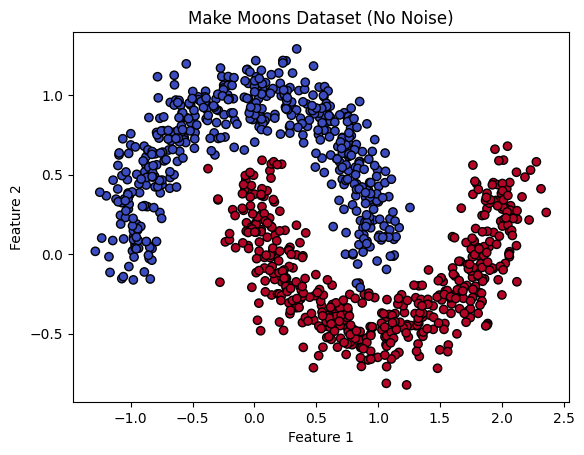

In [60]:
X_dummy, Y_dummy = make_moons(n_samples=1000, noise=0.13, random_state=42)
plt.scatter(X_dummy[:, 0], X_dummy[:, 1], c=Y_dummy, cmap='coolwarm', edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Make Moons Dataset (No Noise)')
plt.show()


In [61]:
import imageio
import os

# Set your image directory and output path
image_folder = r"C:\Users\jitik\OneDrive\Desktop\Hands_on_ML_aurelion_geron\Chapter_10_geron\decision_boundary_moons_dir"
output_gif = "decision_boundary_animation_moons.gif"  # Saves in the current directory

# Collect all .png files in sorted order (so epochs are in sequence)
image_files = sorted([f for f in os.listdir(image_folder) if f.endswith('.png')])

# Read each image, append to list
images = []
for file_name in image_files:
    file_path = os.path.join(image_folder, file_name)
    images.append(imageio.imread(file_path))

# Save as GIF (duration: seconds per frame)
imageio.mimsave(output_gif, images, duration=0.2)
print("GIF saved as:", output_gif)


C:\Users\jitik\AppData\Local\Temp\ipykernel_47872\4103294794.py:15: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file_path))


GIF saved as: decision_boundary_animation_moons.gif


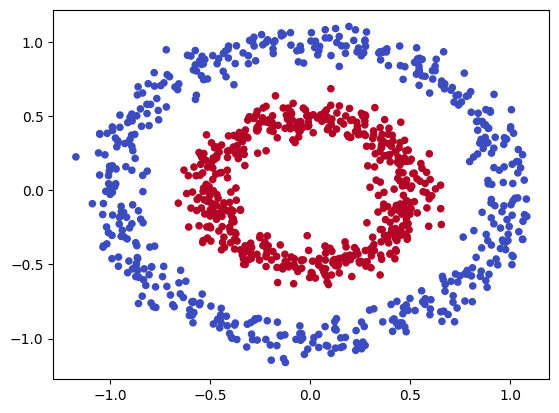

In [62]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

X, Y = make_circles(n_samples=1000, noise=0.07, factor=0.5, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.coolwarm, s=20)
plt.show()

In [63]:
X_train,Y_train,X_test,Y_test = X[:800],Y[:800],X[200:],Y[200:]

input_dimension = 2
output_dimension = 2
layer_dimension = (5,5,output_dimension)
num_classes = output_dimension
epochs = 200
test_size = X_train.shape[0]
batch_size = X_train.shape[0]
learning_rate_moons = 0.02

weights_matrix_final, bias_matrix_final, average_loss_history, accuracy_history,loss_history = train_neural_network(X_train,Y_train,X_test,Y_test,input_dimension,layer_dimension,num_classes,epochs,learning_rate_moons,batch_size=batch_size,decision_boundary=True,decision_boundary_save_dir=r'C:\Users\jitik\OneDrive\Desktop\Hands_on_ML_aurelion_geron\Chapter_10_geron\decision_boundary_circles_dir')

Epoch 0: average_loss = 547.8330,entropy_loss = 547.8330, test accuracy = 55.50%
Epoch 1: average_loss = 535.5737,entropy_loss = 535.5737, test accuracy = 58.13%
Epoch 2: average_loss = 523.9482,entropy_loss = 523.9482, test accuracy = 60.88%
Epoch 3: average_loss = 511.4949,entropy_loss = 511.4949, test accuracy = 63.00%
Epoch 4: average_loss = 499.1093,entropy_loss = 499.1093, test accuracy = 64.75%
Epoch 5: average_loss = 487.4710,entropy_loss = 487.4710, test accuracy = 75.12%
Epoch 6: average_loss = 477.6934,entropy_loss = 477.6934, test accuracy = 74.62%
Epoch 7: average_loss = 466.4776,entropy_loss = 466.4776, test accuracy = 82.62%
Epoch 8: average_loss = 455.4429,entropy_loss = 455.4429, test accuracy = 80.62%
Epoch 9: average_loss = 444.8833,entropy_loss = 444.8833, test accuracy = 86.38%
Epoch 10: average_loss = 434.1362,entropy_loss = 434.1362, test accuracy = 81.00%
Epoch 11: average_loss = 425.5543,entropy_loss = 425.5543, test accuracy = 87.62%
Epoch 12: average_loss = 4

In [64]:
import imageio
import os

# Set your image directory and output path
image_folder = r"C:\Users\jitik\OneDrive\Desktop\Hands_on_ML_aurelion_geron\Chapter_10_geron\decision_boundary_circles_dir"
output_gif = "decision_boundary_animation_circles.gif"  # Saves in the current directory

# Collect all .png files in sorted order (so epochs are in sequence)
image_files = sorted([f for f in os.listdir(image_folder) if f.endswith('.png')])

# Read each image, append to list
images = []
for file_name in image_files:
    file_path = os.path.join(image_folder, file_name)
    images.append(imageio.imread(file_path))

# Save as GIF (duration: seconds per frame)
imageio.mimsave(output_gif, images, duration=0.2)
print("GIF saved as:", output_gif)


C:\Users\jitik\AppData\Local\Temp\ipykernel_47872\3170794203.py:15: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file_path))


GIF saved as: decision_boundary_animation_circles.gif


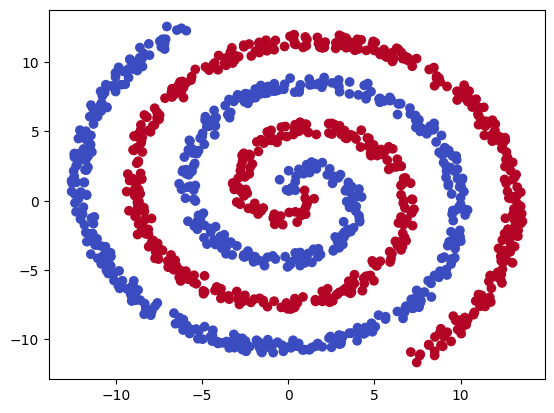

In [69]:
import numpy as np
import matplotlib.pyplot as plt

def make_spiral(n_points, noise=0.5):
    n = np.sqrt(np.random.rand(n_points,1)) * 780 * (2*np.pi)/360
    d1x = -np.cos(n)*n + np.random.rand(n_points,1) * noise
    d1y = np.sin(n)*n + np.random.rand(n_points,1) * noise
    X1 = np.hstack((d1x,d1y))
    y1 = np.zeros(n_points)

    d2x = np.cos(n)*n + np.random.rand(n_points,1) * noise
    d2y = -np.sin(n)*n + np.random.rand(n_points,1) * noise
    X2 = np.hstack((d2x,d2y))
    y2 = np.ones(n_points)

    X = np.vstack((X1, X2))
    Y = np.hstack((y1, y2))
    return X, Y

X, Y = make_spiral(600, noise=1)
plt.scatter(X[:,0], X[:,1], c=Y, cmap=plt.cm.coolwarm)
plt.show()


In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

input_dimension = 2
output_dimension = 2
layer_dimension = (64, 32, 24, 16,8, output_dimension)
num_classes = output_dimension
epochs = 500
test_size = X_train.shape[0]
# batch_size = X_train.shape[0]
batch_size = 32
learning_rate_moons = 0.001

weights_matrix_final, bias_matrix_final, average_loss_history, accuracy_history,loss_history = train_neural_network(X_train,Y_train,X_test,Y_test,input_dimension,layer_dimension,num_classes,epochs,learning_rate_moons,batch_size=batch_size,decision_boundary=True,decision_boundary_save_dir=r'C:\Users\jitik\OneDrive\Desktop\Hands_on_ML_aurelion_geron\Chapter_10_geron\decision_boundary_spiral_dir')

Epoch 0: average_loss = 22.2608,entropy_loss = 2226.0846, test accuracy = 61.25%
Epoch 1: average_loss = 21.1810,entropy_loss = 2118.0988, test accuracy = 54.00%
Epoch 2: average_loss = 21.1331,entropy_loss = 2113.3088, test accuracy = 61.38%
Epoch 3: average_loss = 20.9885,entropy_loss = 2098.8459, test accuracy = 62.25%
Epoch 4: average_loss = 20.9695,entropy_loss = 2096.9547, test accuracy = 64.12%
Epoch 5: average_loss = 20.7889,entropy_loss = 2078.8928, test accuracy = 62.50%
Epoch 6: average_loss = 20.8308,entropy_loss = 2083.0761, test accuracy = 61.88%
Epoch 7: average_loss = 20.8411,entropy_loss = 2084.1136, test accuracy = 61.12%
Epoch 8: average_loss = 20.7436,entropy_loss = 2074.3584, test accuracy = 61.75%
Epoch 9: average_loss = 20.7535,entropy_loss = 2075.3541, test accuracy = 63.12%
Epoch 10: average_loss = 20.6925,entropy_loss = 2069.2479, test accuracy = 62.25%
Epoch 11: average_loss = 20.6947,entropy_loss = 2069.4677, test accuracy = 62.38%
Epoch 12: average_loss = 2

In [38]:
import imageio
import os

# Set your image directory and output path
image_folder = r"C:\Users\jitik\OneDrive\Desktop\Hands_on_ML_aurelion_geron\Chapter_10_geron\decision_boundary_spiral_dir"
output_gif = "decision_boundary_animation_spiral.gif"  # Saves in the current directory

# Collect all .png files in sorted order (so epochs are in sequence)
image_files = sorted([f for f in os.listdir(image_folder) if f.endswith('.png')])

# Read each image, append to list
images = []
for file_name in image_files:
    file_path = os.path.join(image_folder, file_name)
    images.append(imageio.imread(file_path))

# Save as GIF (duration: seconds per frame)
imageio.mimsave(output_gif, images, duration=0.2)
print("GIF saved as:", output_gif)


C:\Users\jitik\AppData\Local\Temp\ipykernel_29348\3539802801.py:15: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(file_path))


GIF saved as: decision_boundary_animation_spiral.gif
